# Customer Purchase Prediction using Machine learning
**Objective:Predict whether a customer will purchase a product based on age and salary.**

**import Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

**Load And Check Data**

In [44]:
df=pd.read_csv("data.csv")
print(df.head())
df=df.drop_duplicates()
df=df.dropna()
print(df.shape)
print(df.info())

   Age  EstimatedSalary  Purchased
0   56            45342          0
1   46            57157          1
2   32            87863          1
3   25            72083          0
4   38            85733          1
(200, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              200 non-null    int64
 1   EstimatedSalary  200 non-null    int64
 2   Purchased        200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB
None


**Check missing values**

In [27]:
print(df.isnull().sum())

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


***Prepare*** **Data**

In [12]:
X=df[['Age','EstimatedSalary']]
Y=df['Purchased']

**Statistics**

In [26]:
print(df.describe())

              Age  EstimatedSalary   Purchased
count  200.000000       200.000000  200.000000
mean    38.665000     67700.155000    0.510000
std     12.604648     29207.658499    0.501154
min     18.000000     20301.000000    0.000000
25%     27.750000     42278.750000    0.000000
50%     40.000000     67293.500000    1.000000
75%     49.250000     92235.000000    1.000000
max     59.000000    119713.000000    1.000000


 **Split Data**

In [13]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.2)

**Train And Evaluate mode**

In [18]:
model = LogisticRegression()
model.fit(Xtrain, Ytrain)
y_pred=model.predict(Xtest)
accuracy=accuracy_score(Ytest,y_pred)
print("Accuracy",accuracy)

Accuracy 0.875


**Model Score**

In [41]:
print("Train score:",model.score(Xtrain,Ytrain))
print("Test score:",model.score(Xtest,Ytest))

Train score: 0.86875
Test score: 0.875


# Plotting

**Predicted Vs Actual**

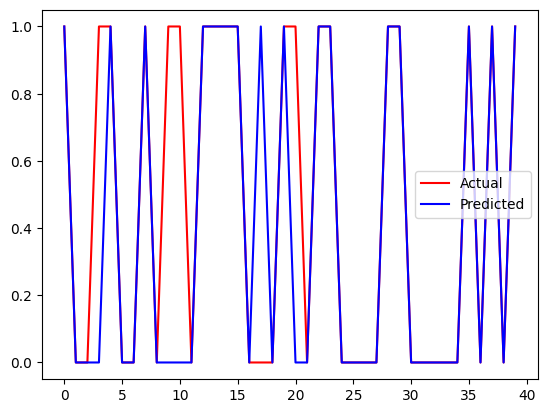

In [61]:
plt.plot(Ytest.values,color="red", label="Actual")
plt.plot(y_pred,color="blue", label="Predicted")
plt.legend()
plt.show()

**Purchased Vs Age**

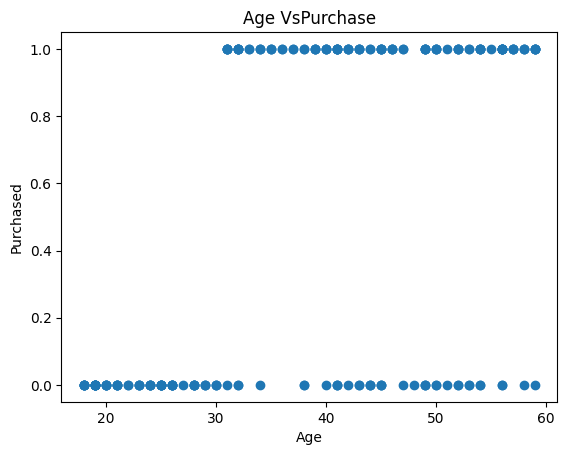

In [47]:
plt.scatter(df['Age'],df['Purchased'])
plt.xlabel("Age")
plt.ylabel("Purchased")
plt.title("Age VsPurchase")
plt.show()

# Salary Vs Purchase

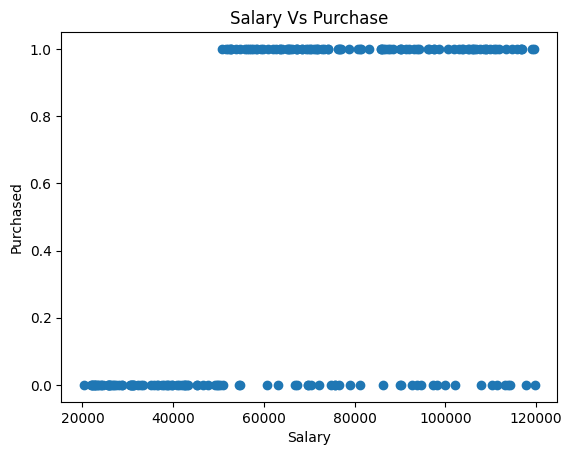

In [46]:
plt.figure()
plt.scatter(df['EstimatedSalary'],df['Purchased'])
plt.title("Salary Vs Purchase")
plt.xlabel("Salary")
plt.ylabel("Purchased")
plt.show()

**Test Multiple Values**

In [58]:
tests=[[20,2000],[40,9000],[55,120000],[30,50000]]
for t in tests:
    test_df = pd.DataFrame([t], columns=['Age', 'EstimatedSalary'])
    prediction=model.predict(test_df)
    print(t,"=>",prediction)

[20, 2000] => [0]
[40, 9000] => [0]
[55, 120000] => [1]
[30, 50000] => [0]
